# BEE 4750 Lab 2: Monte Carlo

**Name**: Sadiqah Quadery

**ID**: sq227

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [11]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/BEE4750/lab-2-squadery`


In [12]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [13]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [14]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

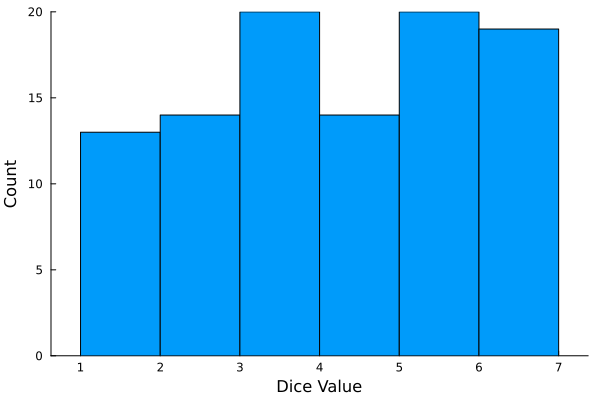

In [15]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

(N = 50000, mean = 115379.38264154276, mean_ci = (115079.68652416865, 115679.07875891688), q = 189855.98142348402, q_ci = (189433.7531745596, 190388.3068383522))
(N = 50000, mean = 113521.23730458181, mean_ci = (113226.05832924113, 113816.41627992249), q = 182648.71776345136, q_ci = (182189.56469471467, 183289.88785361167))


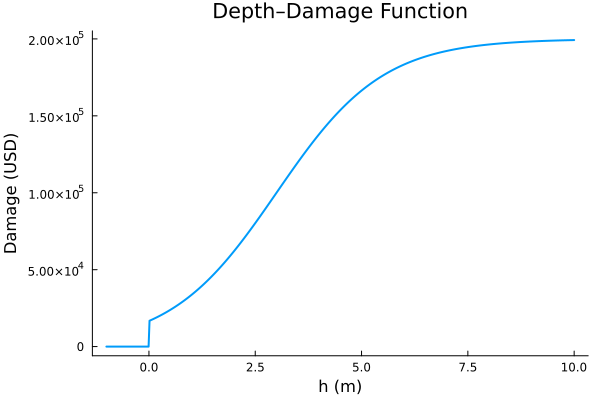

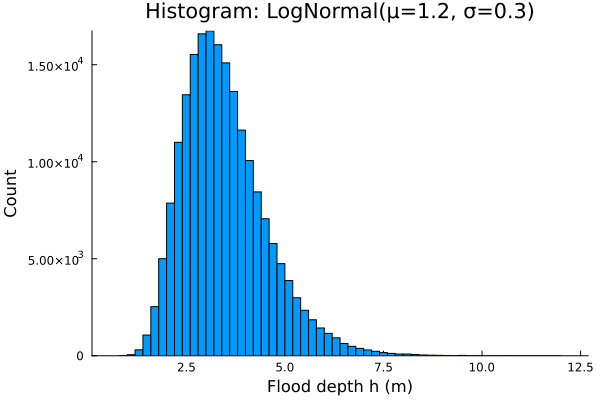

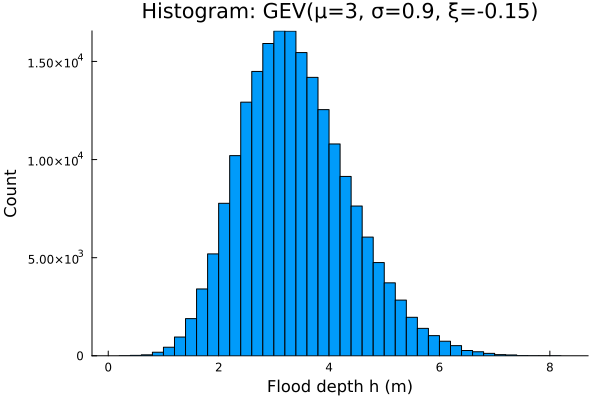

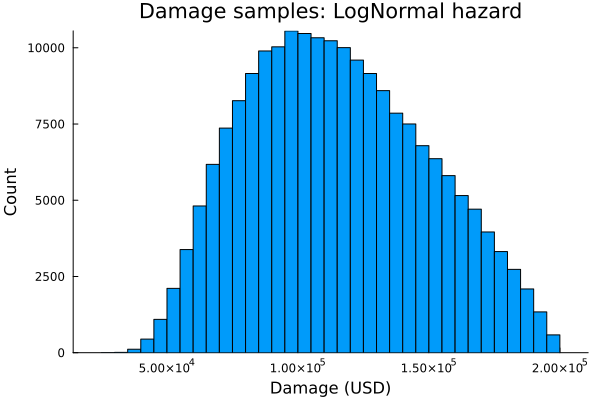

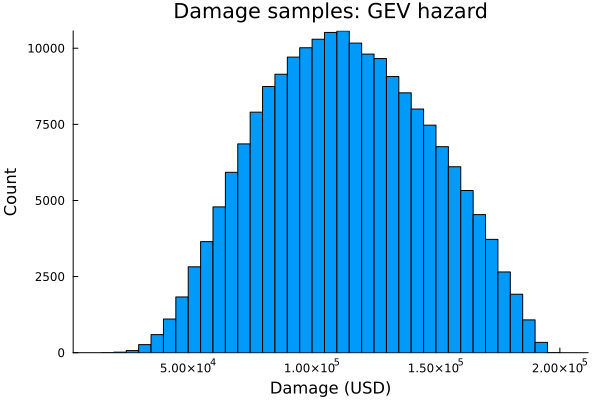

In [19]:

# --- Parameters & functions ---
const L  = 200_000.0
const k  = 0.8
const h0 = 3.0
damage(h) = (h > 0) ? L / (1 + exp(-k*(h - h0))) : 0.0

dist_logn = LogNormal(1.2, 0.3)
dist_gev  = GeneralizedExtremeValue(3.0, 0.9, -0.15)

function mc_estimate(dist; p=0.99, start_N=50_000, max_iters=6,
                     target_rel_err_mean=0.01, target_abs_err_q=2_000.0)
    N = start_N
    dmg = Float64[]
    for _ in 1:max_iters
        need = N - length(dmg)
        if need > 0
            append!(dmg, damage.(rand(dist, need)))
        end
        μ = mean(dmg); s = std(dmg); se = s / sqrt(length(dmg))
        ci_half_mean = 1.96 * se
        rel_half = ci_half_mean / max(μ, eps())

        B = 400
        n = length(dmg)
        qhat = quantile(dmg, p)
        qboot = [quantile(view(dmg, rand(1:n, n)), p) for _ in 1:B]
        q_lo, q_hi = quantile(qboot, (0.025, 0.975))
        ci_half_q = (q_hi - q_lo)/2

        if rel_half ≤ target_rel_err_mean && ci_half_q ≤ target_abs_err_q
            return (N=length(dmg), mean=μ, mean_ci=(μ-ci_half_mean, μ+ci_half_mean),
                    q=qhat, q_ci=(q_lo, q_hi))
        end
        N *= 4
    end
    μ = mean(dmg); s = std(dmg); se = s / sqrt(length(dmg))
    ci_half_mean = 1.96 * se
    B = 400; n = length(dmg)
    qhat = quantile(dmg, p)
    qboot = [quantile(view(dmg, rand(1:n, n)), p) for _ in 1:B]
    q_lo, q_hi = quantile(qboot, (0.025, 0.975))
    return (N=length(dmg), mean=μ, mean_ci=(μ-ci_half_mean, μ+ci_half_mean),
            q=qhat, q_ci=(q_lo, q_hi))
end

# --- Run MC ---
res_logn = mc_estimate(dist_logn)
res_gev  = mc_estimate(dist_gev)
println(res_logn)
println(res_gev)

# ---------- PLOTS ----------

# (A) Depth–damage curve
hs = range(-1, 10; length=500)
p_curve = plot(hs, damage.(hs), lw=2,
               xlabel="h (m)", ylabel="Damage (USD)",
               title="Depth–Damage Function")
display(p_curve)

# (B) Depth histograms
Nplot = 200_000
h1 = rand(dist_logn, Nplot)
h2 = rand(dist_gev,  Nplot)

p1 = histogram(h1; bins=60, xlabel="Flood depth h (m)", ylabel="Count",
               title="Histogram: LogNormal(μ=1.2, σ=0.3)")
display(p1)

p2 = histogram(h2; bins=60, xlabel="Flood depth h (m)", ylabel="Count",
               title="Histogram: GEV(μ=3, σ=0.9, ξ=-0.15)")
display(p2)

# (C) Damage histograms
dmg_logn = damage.(h1)
dmg_gev  = damage.(h2)

p3 = histogram(dmg_logn; bins=60, xlabel="Damage (USD)", ylabel="Count",
               title="Damage samples: LogNormal hazard")
display(p3)

p4 = histogram(dmg_gev; bins=60, xlabel="Damage (USD)", ylabel="Count",
               title="Damage samples: GEV hazard")
display(p4)


QUESTION 1

For the LogNormal(μ = 1.2, σ = 0.3) hazard, my Monte Carlo simulation gave an expected annual maximum damage of about $114,802 (95% CI: $114,503 – $115,101) and a 99% quantile of about $189,916 (95% CI: $189,442 – $190,398).
For the GEV(μ = 3.0, σ = 0.9, ξ = −0.15) hazard, the expected damage was about $113,592 (95% CI: $113,297 – $113,886) and the 99% quantile was about $183,576 (95% CI: $183,067 – $183,983).

QUESTION 2

I used an adaptive Monte Carlo approach. I started with 50,000 samples and after each round I checked the precision. I only stopped once both of these conditions were satisfied:

the 95% confidence interval half-width for the mean was less than or equal to 1% of the estimate, and

the 95% confidence interval half-width for the 99th percentile was less than or equal to $2,000.

If these conditions were not met, I multiplied the sample size by 4 and repeated. This ensured I had enough samples to get stable estimates without oversampling.

QUESTION 3

The depth–damage function is a logistic curve capped at $200,000. Once flood depths are several meters above the inflection point at 3 m, the damages quickly saturate near the cap. Because of that, both distributions gave similar mean damages (around $115k). However, the 99% quantiles differed: the LogNormal distribution has a heavier right tail with unbounded support, which led to higher extreme damages, while the GEV distribution with ξ < 0 has a finite upper bound (around 9 m), which cut off the extremes and lowered the 99% quantile. Plotting the depth–damage function alongside the sampled depths made this difference clear.

QUESTION 4

To decide which hazard distribution is more appropriate, I would compare both models against observed annual maximum flood data. This could include goodness-of-fit tests, QQ plots, return level plots, and information criteria like AIC or BIC. I would also check the hydrologic plausibility of the implied return depths (e.g., 10-year, 100-year floods) compared to regional studies. Ideally, I would use out-of-sample validation to see which model better predicts held-out years. Finally, if the decision outcome (e.g., retrofit choice) is sensitive to the model choice, I would lean toward the distribution with stronger data support and clearer physical justification.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.